# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

## 1. Clean the data and perform some EDA

I used the car dataset. The data were already pretty clean, so most of the work was dropping the index column, turning the owner field into a numeric variable, and creating car age from the model year.

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3241/1116334427.py:13: SyntaxWarning: invalid escape sequence '\d'
  df['No_of_Owners_num'] = df['No_of_Owners'].str.extract('(\d)').astype(int)


(976, 13)
Make                 0
Make_Year            0
Color                0
Body_Type            0
Mileage_Run          0
No_of_Owners         0
Seating_Capacity     0
Fuel_Type            0
Transmission         0
Transmission_Type    0
Price                0
No_of_Owners_num     0
Age                  0
dtype: int64

Make                 object
Make_Year             int64
Color                object
Body_Type            object
Mileage_Run           int64
No_of_Owners         object
Seating_Capacity      int64
Fuel_Type            object
Transmission         object
Transmission_Type    object
Price                 int64
No_of_Owners_num      int64
Age                   int64
dtype: object


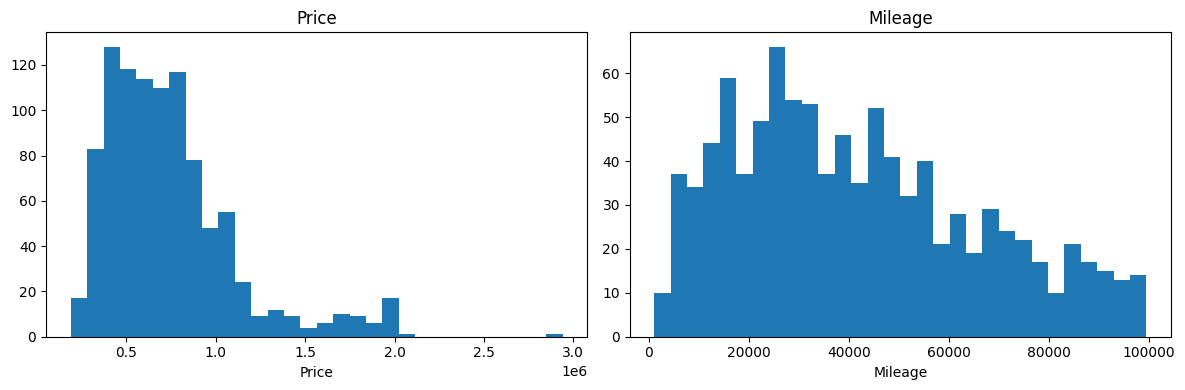

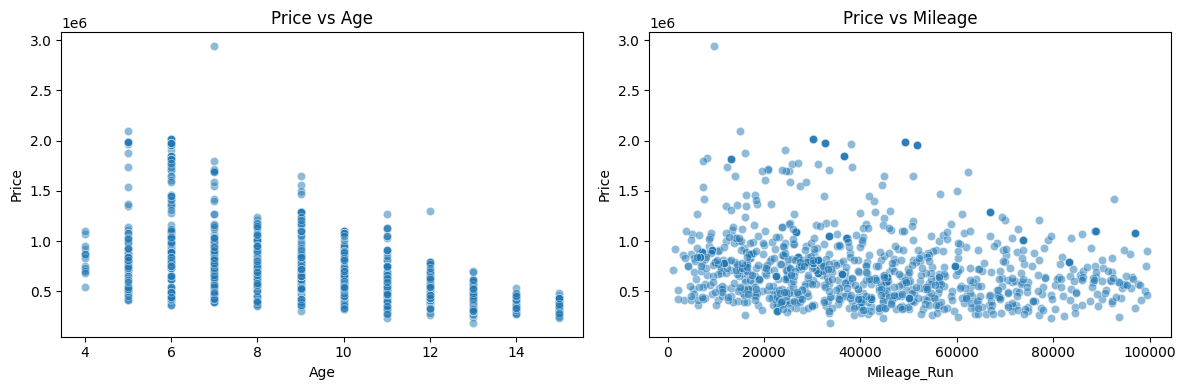

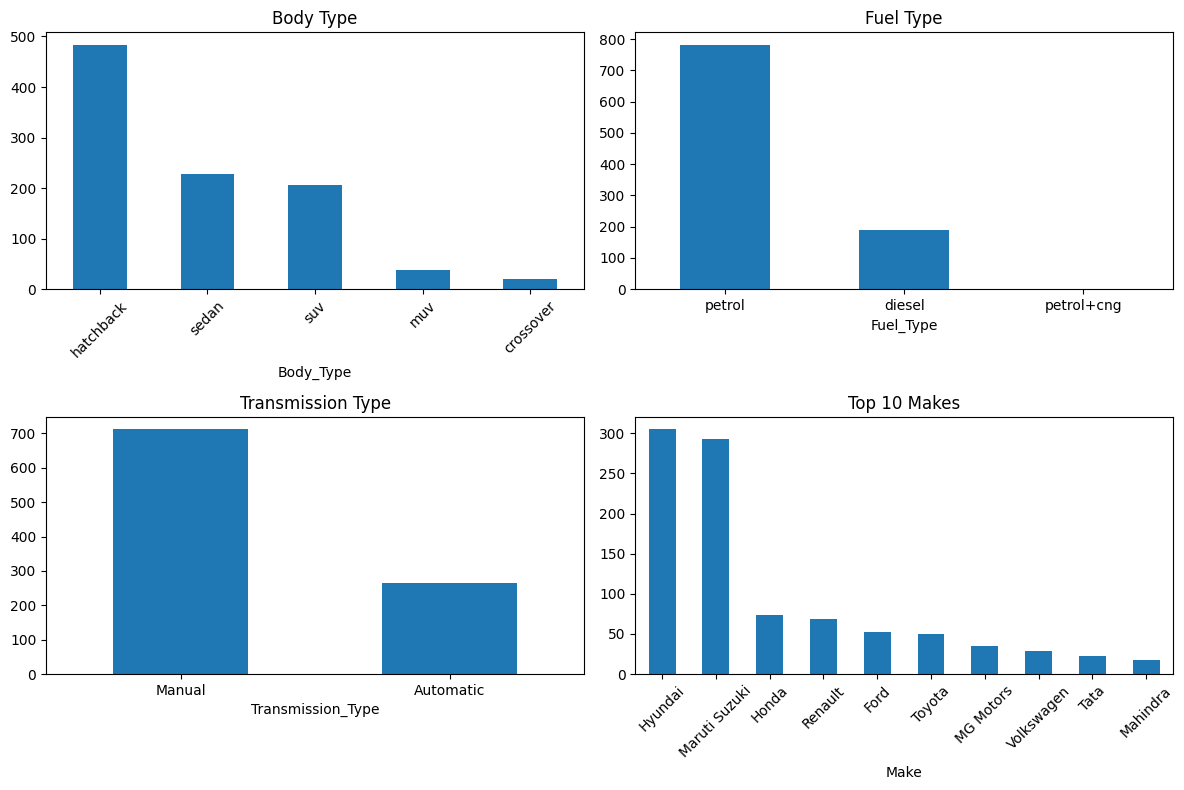

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('/content/cars_hw (1).csv')
df = df.drop(columns=['Unnamed: 0']).copy()

df['No_of_Owners_num'] = df['No_of_Owners'].str.extract('(\d)').astype(int)
df['Age'] = 2026 - df['Make_Year']

print(df.shape)
df.head()

print(df.isna().sum())
print()
print(df.dtypes)

df[['Price','Mileage_Run','Age','No_of_Owners_num','Seating_Capacity']].describe()

fig, ax = plt.subplots(1, 2, figsize=(12,4))
df['Price'].hist(bins=30, ax=ax[0], grid=False)
ax[0].set_title('Price')
ax[0].set_xlabel('Price')

df['Mileage_Run'].hist(bins=30, ax=ax[1], grid=False)
ax[1].set_title('Mileage')
ax[1].set_xlabel('Mileage')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12,4))

sns.scatterplot(data=df, x='Age', y='Price', alpha=.5, ax=ax[0])
ax[0].set_title('Price vs Age')

sns.scatterplot(data=df, x='Mileage_Run', y='Price', alpha=.5, ax=ax[1])
ax[1].set_title('Price vs Mileage')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 2, figsize=(12,8))

df['Body_Type'].value_counts().plot(kind='bar', ax=ax[0,0], title='Body Type')
ax[0,0].tick_params(axis='x', rotation=45)

df['Fuel_Type'].value_counts().plot(kind='bar', ax=ax[0,1], title='Fuel Type')
ax[0,1].tick_params(axis='x', rotation=0)

df['Transmission_Type'].value_counts().plot(kind='bar', ax=ax[1,0], title='Transmission Type')
ax[1,0].tick_params(axis='x', rotation=0)

df['Make'].value_counts().head(10).plot(kind='bar', ax=ax[1,1], title='Top 10 Makes')
ax[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Quick EDA takeaway:**  
Price falls as cars get older and more used. Price is also pretty right-skewed. Hatchbacks are the most common body type, petrol is the most common fuel type, and Hyundai plus Maruti Suzuki make up a big chunk of the sample.

2. Transform the variables, especially categorical ones

For regression, I kept the numeric variables as numeric and turned the categorical variables into dummies with pd.get_dummies(..., drop_first=True) so I would avoid the dummy variable trap.

In [7]:
num_cols = ['Age','Mileage_Run','No_of_Owners_num','Seating_Capacity']
cat_cols_main = ['Make','Body_Type','Fuel_Type','Transmission_Type']
cat_cols_all = ['Make','Body_Type','Fuel_Type','Transmission_Type','Color','Transmission']



I split the data once and set `random_state=3001` so the results stay the same.

In [8]:
train_df, test_df = train_test_split(df, test_size=.2, random_state=3001)

print(train_df.shape)
print(test_df.shape)

(780, 13)
(196, 13)


## 4. Build simple linear models with no transformations or interactions

I tried three simple models:

- **Model 1:** numeric variables only  
- **Model 2:** numeric variables + main categorical dummies  
- **Model 3:** numeric variables + all categorical dummies  

Then I compared RMSE and $R^2$ on both train and test data.

In [10]:
def rmse(y, yhat):
    return np.sqrt(mean_squared_error(y, yhat))

def fit_and_score(X_train, X_test, y_train, y_test, name):
    reg = LinearRegression()
    reg.fit(X_train, y_train)

    yhat_train = reg.predict(X_train)
    yhat_test = reg.predict(X_test)

    out = {
        'model': name,
        'train_rmse': rmse(y_train, yhat_train),
        'test_rmse': rmse(y_test, yhat_test),
        'train_r2': r2_score(y_train, yhat_train),
        'test_r2': r2_score(y_test, yhat_test)
    }

    return reg, out


y_train = train_df['Price']
y_test = test_df['Price']

X1_train = train_df[num_cols]
X1_test = test_df[num_cols]

m1, r1 = fit_and_score(X1_train, X1_test, y_train, y_test, 'numeric only')

X2_train = pd.get_dummies(train_df[num_cols + cat_cols_main], drop_first=True, dtype=int)
X2_test = pd.get_dummies(test_df[num_cols + cat_cols_main], drop_first=True, dtype=int)
X2_test = X2_test.reindex(columns=X2_train.columns, fill_value=0)

m2, r2 = fit_and_score(X2_train, X2_test, y_train, y_test, 'numeric + main dummies')

X3_train = pd.get_dummies(train_df[num_cols + cat_cols_all], drop_first=True, dtype=int)
X3_test = pd.get_dummies(test_df[num_cols + cat_cols_all], drop_first=True, dtype=int)
X3_test = X3_test.reindex(columns=X3_train.columns, fill_value=0)

m3, r3 = fit_and_score(X3_train, X3_test, y_train, y_test, 'numeric + all dummies')

simple_results = pd.DataFrame([r1, r2, r3]).sort_values('test_rmse')
simple_results

,model,train_rmse,test_rmse,train_r2,test_r2
2,numeric + all dummies,142592.520450,139355.437335,0.856012,0.818754
1,numeric + main dummies,154152.059830,143675.826988,0.831721,0.807342
0,numeric only,311800.670111,272989.469970,0.311529,0.304476


**Answer for Question 4:**  
Out of the simple models, Model 3 (numeric + all dummies) did the best on the test set. It had the lowest test RMSE and the highest test $R^2$, so adding the extra categorical information helped a lot.

## 5. Partial correlation plots for the numeric variables

I used the best simple model from Question 4 and made partial correlation plots for:

- Age
- Mileage_Run
- No_of_Owners_num
- Seating_Capacity

These plots partial out the other regressors first, then show the relationship that is left over.

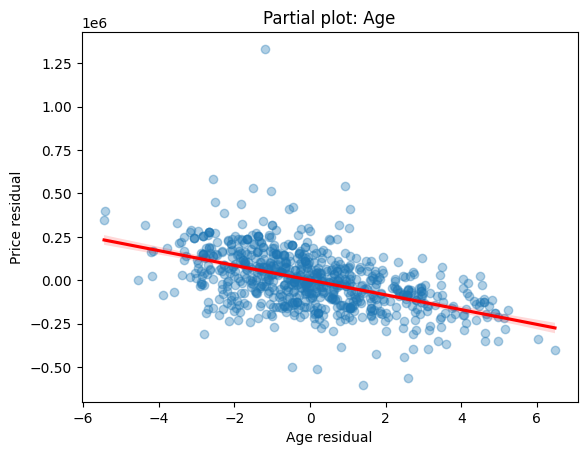

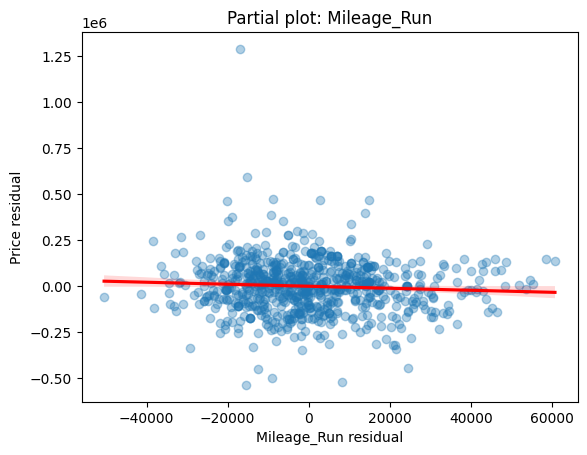

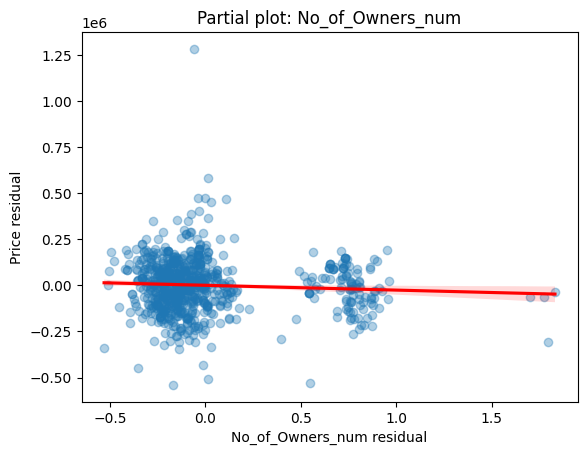

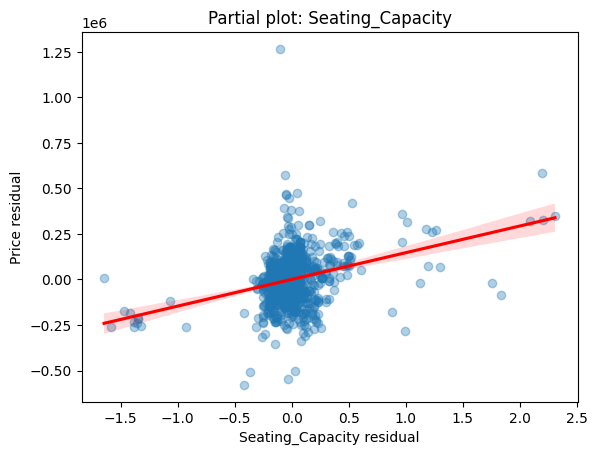

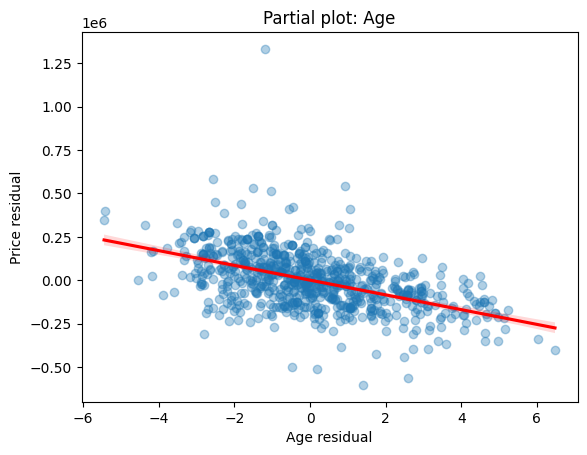

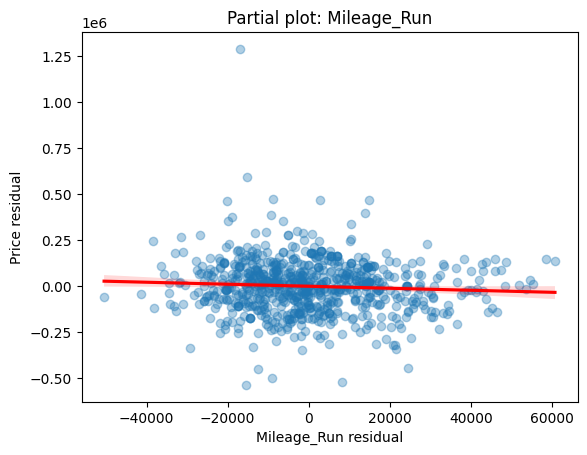

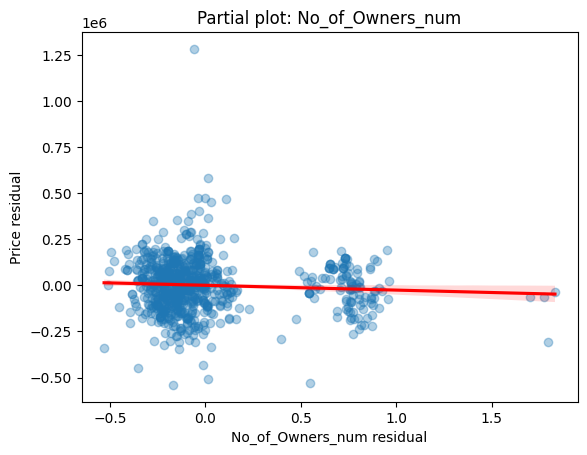

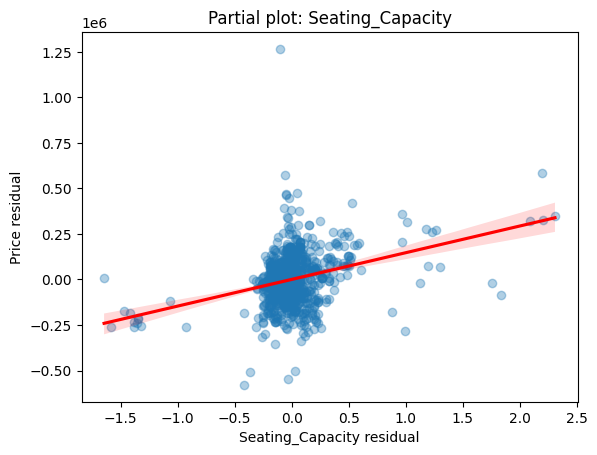

In [16]:
def partial_plot(X, y, var):
    x_k = X[var]
    X_other = X.drop(columns=[var])

    reg_y = LinearRegression(fit_intercept=False).fit(X_other, y)
    r_y = y - reg_y.predict(X_other)

    reg_x = LinearRegression(fit_intercept=False).fit(X_other, x_k)
    r_x = x_k - reg_x.predict(X_other)

    sns.regplot(x=r_x, y=r_y, scatter_kws={'alpha':.35}, line_kws={'color':'red'})
    plt.title('Partial plot: ' + var)
    plt.xlabel(var + ' residual')
    plt.ylabel('Price residual')
    plt.show()


for v in ['Age','Mileage_Run','No_of_Owners_num','Seating_Capacity']:
    partial_plot(X3_train, y_train, v)


for v in ['Age','Mileage_Run','No_of_Owners_num','Seating_Capacity']:
    partial_plot(X3_train, y_train, v)

**Answer for Question 5:**  
Yes, I do notice some nonlinearity. The strongest ones seem to be Mileage_Run and Age. The effect does not look perfectly straight, especially once the other controls are partialed out. That suggested trying a mileage transformation and adding at least one nonlinear term or interaction in the next model.

## 6. Add transformations and interactions and build a more complex model

Based on the partial plots and the right-skew in price, I made these changes:

- transformed Price with arcsinh
- transformed Mileage_Run with arcsinh
- added Age_sq
- added Age_x_mileage
- kept the full set of categorical dummies

Since the dependent variable is transformed, I converted predictions back with np.sinh() before calculating RMSE and $R^2$ on the original price scale.

In [18]:
train2 = train_df.copy()
test2 = test_df.copy()

for d in [train2, test2]:
    d['price_ihs'] = np.arcsinh(d['Price'])
    d['mileage_ihs'] = np.arcsinh(d['Mileage_Run'])
    d['Age_sq'] = d['Age']**2
    d['Age_x_mileage'] = d['Age'] * d['mileage_ihs']

    X4_cols = ['Age','Age_sq','mileage_ihs','Age_x_mileage','No_of_Owners_num','Seating_Capacity'] + cat_cols_all

X4_train = pd.get_dummies(train2[X4_cols], drop_first=True, dtype=int)
X4_test = pd.get_dummies(test2[X4_cols], drop_first=True, dtype=int)
X4_test = X4_test.reindex(columns=X4_train.columns, fill_value=0)

y4_train = train2['price_ihs']
y4_test = test2['price_ihs']

m4 = LinearRegression()
m4.fit(X4_train, y4_train)

pred4_train = np.sinh(m4.predict(X4_train))
pred4_test = np.sinh(m4.predict(X4_test))

complex_results = pd.DataFrame([{
    'model':'transformed + interactions',
    'train_rmse': rmse(train2['Price'], pred4_train),
    'test_rmse': rmse(test2['Price'], pred4_test),
    'train_r2': r2_score(train2['Price'], pred4_train),
    'test_r2': r2_score(test2['Price'], pred4_test)
}])

complex_results

,model,train_rmse,test_rmse,train_r2,test_r2
0,transformed + interactions,143107.679829,134073.515156,0.85497,0.832233


## 7. Compare the models

Now I put the best simple model next to the more complex model.

In [19]:
best_simple = simple_results.iloc[[0]].copy()
all_results = pd.concat([best_simple, complex_results], ignore_index=True)
all_results

,model,train_rmse,test_rmse,train_r2,test_r2
0,numeric + all dummies,142592.520450,139355.437335,0.856012,0.818754
1,transformed + interactions,143107.679829,134073.515156,0.854970,0.832233


**Final answer:**  
The transformed + interactions model did the best overall. It improved the test RMSE compared with the best simple model and also slightly improved test $R^2$. So my final choice would be the model with the arcsinh transformation on price and mileage, plus the age square term and the age-by-mileage interaction.